In [1]:
# ============================================================
# NOTEBOOK : 04_segmentation.ipynb
# READS    : Data/loyalty_dataset.csv
# ADDS     : Customer_Segment
# SAVES    : Data/final_dataset.csv  ← CREATED HERE FIRST TIME
# NEXT     : Load final_dataset.csv into MySQL and Power BI
# ============================================================

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

print(" Libraries loaded")

 Libraries loaded


In [5]:

df = pd.read_csv('../Data/loyalty_dataset.csv')

print(f"\nShape: {df.shape}")
print(f"\nAll columns in dataset:")
for col in df.columns:
    print(f"   {col}")


Shape: (3900, 34)

All columns in dataset:
   Customer_ID
   Age
   Gender
   Item_Purchased
   Category
   Purchase_Amount
   Location
   Size
   Color
   Season
   Review_Rating
   Subscription_Status
   Shipping_Type
   Discount_Applied
   Promo_Code_Used
   Previous_Purchases
   Payment_Method
   Frequency_of_Purchases
   Frequency_Score
   Promo_Dependent
   Satisfaction_Flag
   Tenure_Band
   Spend_Tier
   Customer_Value_Score
   Value_Tier
   Promo_Value_Segment
   Age_Group
   Premium_Shipping_Flag
   High_Value_Flag
   Retention_Risk_Score
   Loyalty_Score_A
   Loyalty_Label_A
   Loyalty_Score_B
   Loyalty_Label_B


In [6]:
print("=" * 55)
print("INPUT COLUMN DISTRIBUTIONS — VERIFICATION")
print("=" * 55)

# Critical columns check first
critical_cols = [
    'Loyalty_Label_A', 'Loyalty_Score_A',
    'Loyalty_Label_B', 'Loyalty_Score_B',
    'Tenure_Band', 'High_Value_Flag',
    'Promo_Dependent', 'Retention_Risk_Score',
    'Frequency_Score', 'Value_Tier',
    'Customer_Value_Score', 'Previous_Purchases',
    'Purchase_Amount', 'Review_Rating',
    'Subscription_Status'
]

missing = [c for c in critical_cols if c not in df.columns]

if missing:
    print(f"\n MISSING COLUMNS: {missing}")
    print("Go back and check notebooks 02 and 03 ran correctly")
    print("Do NOT proceed until these columns exist")
else:
    print("\n All critical columns present. Safe to proceed.\n")

    print("Loyalty_Label_A distribution:")
    print(df['Loyalty_Label_A'].value_counts())

    print("\nLoyalty_Label_B distribution:")
    print(df['Loyalty_Label_B'].value_counts())

    print("\nTenure_Band distribution:")
    print(df['Tenure_Band'].value_counts())

    print("\nHigh_Value_Flag distribution:")
    print(df['High_Value_Flag'].value_counts())

    print("\nPromo_Dependent distribution:")
    print(df['Promo_Dependent'].value_counts())

    print("\nRetention_Risk_Score distribution:")
    print(df['Retention_Risk_Score'].value_counts().sort_index())

    print("\nFrequency_Score (purchases per year):")
    print(df['Frequency_Score'].value_counts().sort_values(ascending=False))

    print("\nValue_Tier distribution:")
    print(df['Value_Tier'].value_counts())

INPUT COLUMN DISTRIBUTIONS — VERIFICATION

 All critical columns present. Safe to proceed.

Loyalty_Label_A distribution:
Loyalty_Label_A
Loyal            1336
Developing       1289
Transactional    1275
Name: count, dtype: int64

Loyalty_Label_B distribution:
Loyalty_Label_B
Loyal            1326
Developing       1288
Transactional    1286
Name: count, dtype: int64

Tenure_Band distribution:
Tenure_Band
Growing        1178
Established    1167
Veteran         847
New             708
Name: count, dtype: int64

High_Value_Flag distribution:
High_Value_Flag
0    2245
1    1655
Name: count, dtype: int64

Promo_Dependent distribution:
Promo_Dependent
0    2223
1    1677
Name: count, dtype: int64

Retention_Risk_Score distribution:
Retention_Risk_Score
0     942
1    1584
2    1083
3     291
Name: count, dtype: int64

Frequency_Score (purchases per year):
Frequency_Score
4     1147
26    1089
1      572
12     553
52     539
Name: count, dtype: int64

Value_Tier distribution:
Value_Tier
Silv

In [7]:
# ─────────────────────────────────────────────────────────────
# SEGMENTATION LOGIC
#
# IMPORTANT PRIORITY ORDER NOTES:
#
# 1. Champion is checked first — highest priority segment
#    Must be Loyal + High Value + No Promos
#
# 2. Promo Convert Target is checked BEFORE Loyal Customer
#    This is critical — a customer who is High Value +
#    Promo Dependent + Veteran would qualify for BOTH
#    Loyal Customer and Promo Convert Target.
#    We must catch them as Promo Convert Target first
#    because they are the core of our sunset plan.
#    If Loyal Customer came first they would be
#    miscategorised and the sunset plan segment
#    would be severely undercounted.
#
# 3. Growth Potential uses Frequency >= 4 (Quarterly+)
#    not >= 12 (Monthly+) to ensure meaningful numbers
#
# 4. At Risk uses score >= 3 which is the maximum
#    possible (Low Satisfaction + Promo Dependent)
#
# Every segment is traceable to exact column values.
# ─────────────────────────────────────────────────────────────

def assign_segment(row):

    # ── SEGMENT 1: CHAMPION ───────────────────────────────────
    # Loyal (Model A) + High Value + No Promos
    # Best customers. Buy often, spend high, never need discount.
    # Highest priority — checked first.
    if (row['Loyalty_Label_A'] == 'Loyal' and
        row['High_Value_Flag'] == 1 and
        row['Promo_Dependent'] == 0):
        return 'Champion'

    # ── SEGMENT 2: PROMO CONVERT TARGET ──────────────────────
    # High Value + Promo Dependent + Long Tenure
    # CHECKED BEFORE Loyal Customer intentionally.
    # These are high-value established customers who always
    # use discounts. Core target for the promotional
    # sunset plan. Most important business segment.
    elif (row['High_Value_Flag'] == 1 and
          row['Promo_Dependent'] == 1 and
          row['Tenure_Band'] in ['Veteran', 'Established']):
        return 'Promo Convert Target'

    # ── SEGMENT 3: LOYAL CUSTOMER ────────────────────────────
    # Loyal (Model A) + Long Tenure
    # Comes after Promo Convert Target so high-value
    # promo users are correctly identified above first.
    elif (row['Loyalty_Label_A'] == 'Loyal' and
          row['Tenure_Band'] in ['Veteran', 'Established']):
        return 'Loyal Customer'

    # ── SEGMENT 4: AT RISK ───────────────────────────────────
    # Retention Risk Score = 3 (maximum possible score)
    # Means: Low Satisfaction AND Promo Dependent
    # Do not remove promos yet — fix satisfaction first.
    elif row['Retention_Risk_Score'] >= 3:
        return 'At Risk'

    # ── SEGMENT 5: GROWTH POTENTIAL ──────────────────────────
    # Frequency >= 4 (Quarterly or more) + New/Growing + No Promos
    # Buying without discounts but still building tenure.
    # Nurture correctly and they can become Champions.
    elif (row['Frequency_Score'] >= 4 and
          row['Tenure_Band'] in ['Growing', 'New'] and
          row['Promo_Dependent'] == 0):
        return 'Growth Potential'

    # ── SEGMENT 6: DISCOUNT DEPENDENT ────────────────────────
    # Promo Dependent + Low Value + New/Growing tenure
    # Only buy with discounts, not yet established.
    # No marketing investment recommended.
    elif (row['Promo_Dependent'] == 1 and
          row['High_Value_Flag'] == 0 and
          row['Tenure_Band'] in ['New', 'Growing']):
        return 'Discount Dependent'

    # ── SEGMENT 7: LOW ENGAGEMENT ────────────────────────────
    # Does not fit any actionable profile above.
    # Monitor only — no active campaign.
    else:
        return 'Low Engagement'

In [8]:
df['Customer_Segment'] = df.apply(assign_segment, axis=1)

print(" Customer_Segment column created")
print(f"\nTotal customers segmented : {len(df)}")
print(f"Unique segments assigned  : {df['Customer_Segment'].nunique()}")

print(f"\nSegment Distribution (count):")
print(df['Customer_Segment'].value_counts())

print(f"\nSegment Distribution (% of total):")
print((df['Customer_Segment'].value_counts(normalize=True) * 100).round(1))

# ── Health check — warn if any segment is empty or too small
print(f"\nSegment health check:")
print("─" * 55)

expected_segments = [
    'Champion',
    'Promo Convert Target',
    'Loyal Customer',
    'At Risk',
    'Growth Potential',
    'Discount Dependent',
    'Low Engagement'
]

all_healthy = True
for seg in expected_segments:
    count = (df['Customer_Segment'] == seg).sum()
    pct   = (df['Customer_Segment'] == seg).mean() * 100
    if count == 0:
        print(f"   {seg:<25} : EMPTY — check segment logic in Cell 5")
        all_healthy = False
    elif pct < 1.0:
        print(f"  {seg:<25} : {count} customers ({pct:.1f}%) — very small")
    else:
        print(f" {seg:<25} : {count} customers ({pct:.1f}%)")

print("─" * 55)
if all_healthy:
    print("\nAll segments populated. Safe to proceed.")
else:
    print("\n Fix empty segments before proceeding.")

 Customer_Segment column created

Total customers segmented : 3900
Unique segments assigned  : 7

Segment Distribution (count):
Customer_Segment
Champion                873
Low Engagement          862
Growth Potential        726
Promo Convert Target    564
Discount Dependent      531
At Risk                 199
Loyal Customer          145
Name: count, dtype: int64

Segment Distribution (% of total):
Customer_Segment
Champion                22.4
Low Engagement          22.1
Growth Potential        18.6
Promo Convert Target    14.5
Discount Dependent      13.6
At Risk                  5.1
Loyal Customer           3.7
Name: proportion, dtype: float64

Segment health check:
───────────────────────────────────────────────────────
 Champion                  : 873 customers (22.4%)
 Promo Convert Target      : 564 customers (14.5%)
 Loyal Customer            : 145 customers (3.7%)
 At Risk                   : 199 customers (5.1%)
 Growth Potential          : 726 customers (18.6%)
 Discount De

In [9]:
#Segment Validation Table
segment_summary = df.groupby('Customer_Segment').agg(
    Customer_Count     = ('Purchase_Amount', 'count'),
    Avg_Spend          = ('Purchase_Amount', 'mean'),
    Avg_Prev_Purchases = ('Previous_Purchases', 'mean'),
    Avg_Frequency      = ('Frequency_Score', 'mean'),
    Avg_CVS            = ('Customer_Value_Score', 'mean'),
    Promo_Pct          = ('Promo_Dependent', 'mean'),
    Avg_Rating         = ('Review_Rating', 'mean'),
    Subscription_Pct   = ('Subscription_Status', 'mean')
).round(2)

# Convert rates to percentages
segment_summary['Promo_Pct']        = (
    segment_summary['Promo_Pct'] * 100
).round(1)

segment_summary['Subscription_Pct'] = (
    segment_summary['Subscription_Pct'] * 100
).round(1)

# Sort by business priority not alphabetically
priority_order = [
    'Champion',
    'Loyal Customer',
    'Promo Convert Target',
    'Growth Potential',
    'At Risk',
    'Discount Dependent',
    'Low Engagement'
]

# Only include segments that actually exist in data
existing = [s for s in priority_order
            if s in segment_summary.index]
segment_summary = segment_summary.reindex(existing)

print("=" * 90)
print("SEGMENT VALIDATION TABLE (sorted by business priority)")
print("=" * 90)
print(segment_summary.to_string())

print("\n")
print("Validation — check these patterns hold:")
print("   Champion       → highest Avg_CVS, lowest Promo_Pct")
print("   Discount Dep   → highest Promo_Pct")
print("   At Risk        → lowest Avg_Rating")
print("   Promo Convert  → high Avg_CVS AND high Promo_Pct")
print("   Champion       → highest Avg_Prev_Purchases")

SEGMENT VALIDATION TABLE (sorted by business priority)
                      Customer_Count  Avg_Spend  Avg_Prev_Purchases  Avg_Frequency  Avg_CVS  Promo_Pct  Avg_Rating  Subscription_Pct
Customer_Segment                                                                                                                    
Champion                         873      65.64               34.32          29.52     0.61        0.0        3.77               0.0
Loyal Customer                   145      37.81               39.65           7.52     0.41        0.0        3.76               0.0
Promo Convert Target             564      65.59               39.54          25.32     0.62      100.0        3.75              66.0
Growth Potential                 726      57.73               11.57          14.41     0.29        0.0        3.73               0.0
At Risk                          199      54.80               19.84          11.61     0.32      100.0        2.72              66.0
Discount Depen

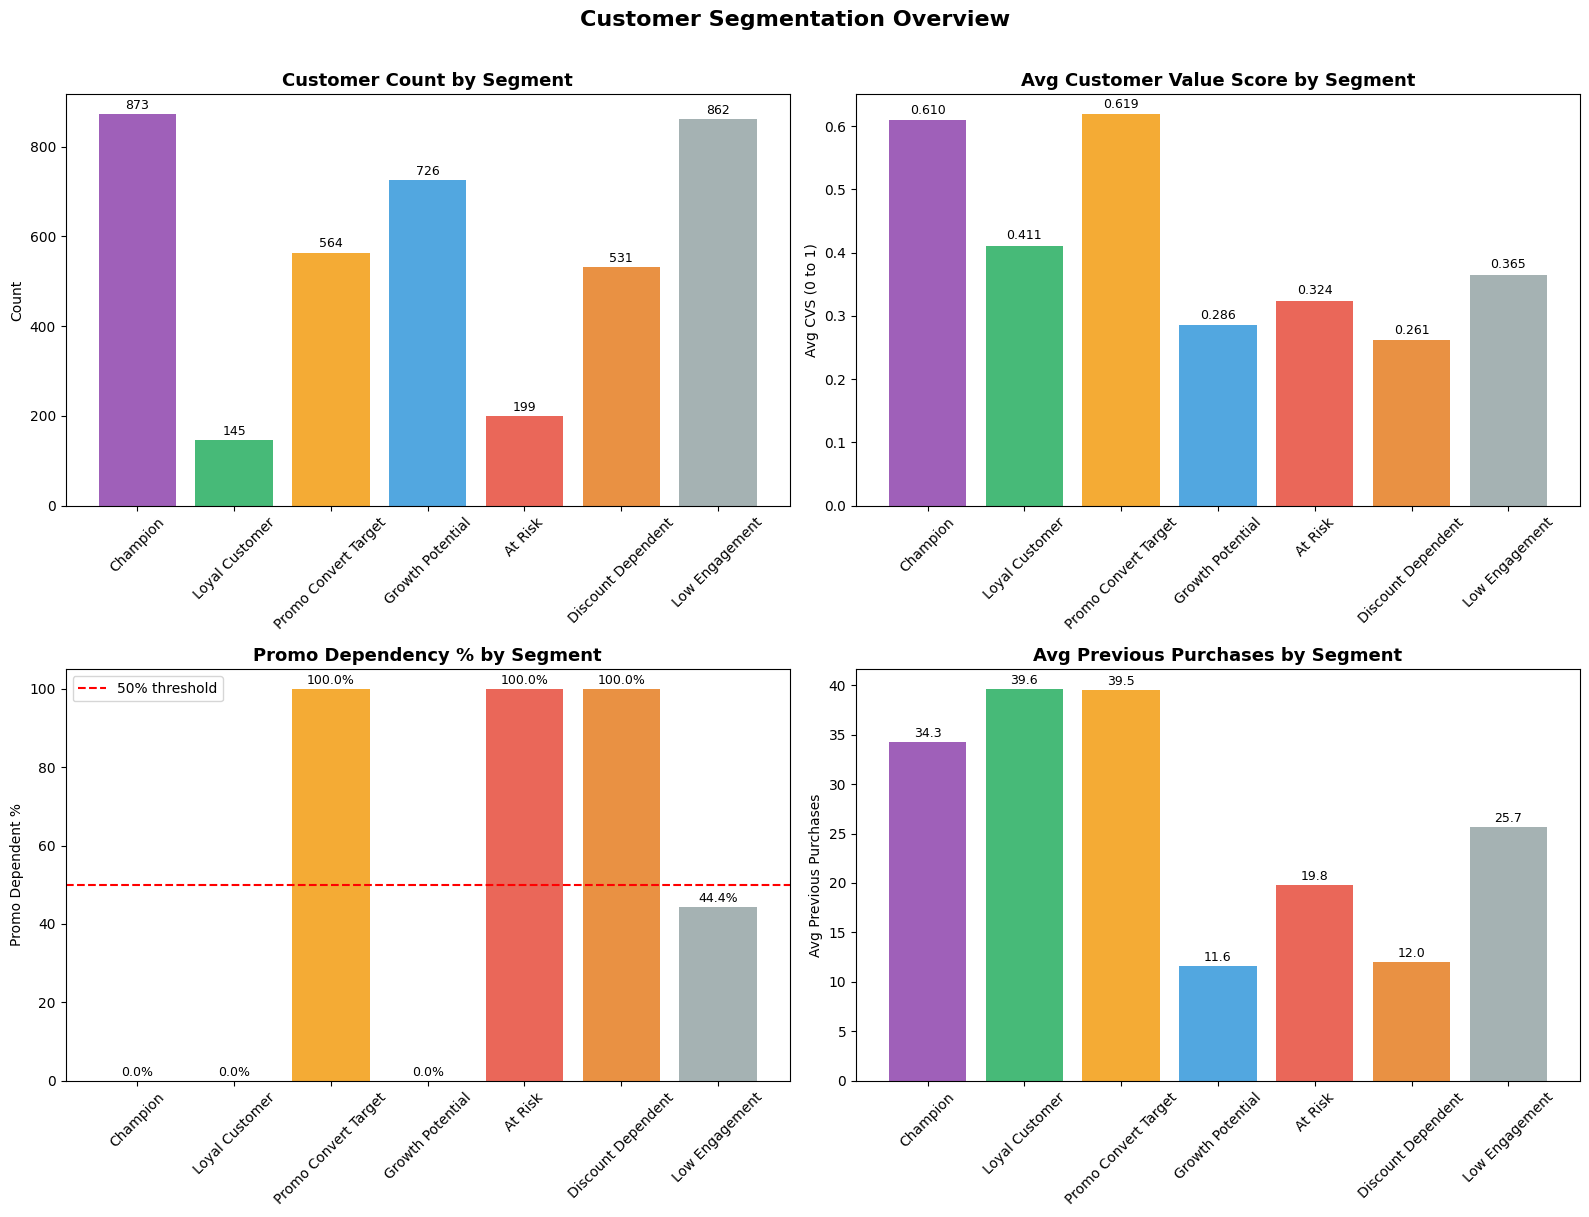

 Chart saved to Screenshots/segmentation_overview.png


In [10]:
# Visualize Segments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define order and colors once
# Same order used for every chart to prevent color mismatch
priority_order = [
    'Champion',
    'Loyal Customer',
    'Promo Convert Target',
    'Growth Potential',
    'At Risk',
    'Discount Dependent',
    'Low Engagement'
]

color_map = {
    'Champion'             : '#8e44ad',
    'Loyal Customer'       : '#27ae60',
    'Promo Convert Target' : '#f39c12',
    'Growth Potential'     : '#3498db',
    'At Risk'              : '#e74c3c',
    'Discount Dependent'   : '#e67e22',
    'Low Engagement'       : '#95a5a6'
}

# Only use segments that exist in actual data
existing  = [s for s in priority_order
             if s in df['Customer_Segment'].unique()]
colors    = [color_map[s] for s in existing]

# ── Plot 1: Customer count
counts = df['Customer_Segment'].value_counts().reindex(existing)
axes[0,0].bar(existing, counts.values, color=colors, alpha=0.85)
axes[0,0].set_title('Customer Count by Segment', fontsize=13,
                     fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 5, str(v),
                   ha='center', va='bottom', fontsize=9)

# ── Plot 2: Avg Customer Value Score
cvs = df.groupby('Customer_Segment')[
    'Customer_Value_Score'].mean().reindex(existing)
axes[0,1].bar(existing, cvs.values, color=colors, alpha=0.85)
axes[0,1].set_title('Avg Customer Value Score by Segment',
                     fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Avg CVS (0 to 1)')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(cvs.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}',
                   ha='center', va='bottom', fontsize=9)

# ── Plot 3: Promo Dependency %
promo = df.groupby('Customer_Segment')[
    'Promo_Dependent'].mean().reindex(existing) * 100
axes[1,0].bar(existing, promo.values, color=colors, alpha=0.85)
axes[1,0].set_title('Promo Dependency % by Segment',
                     fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Promo Dependent %')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=50, color='red', linestyle='--',
                  linewidth=1.5, label='50% threshold')
axes[1,0].legend()
for i, v in enumerate(promo.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)

# ── Plot 4: Avg Previous Purchases
prev = df.groupby('Customer_Segment')[
    'Previous_Purchases'].mean().reindex(existing)
axes[1,1].bar(existing, prev.values, color=colors, alpha=0.85)
axes[1,1].set_title('Avg Previous Purchases by Segment',
                     fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Avg Previous Purchases')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(prev.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}',
                   ha='center', va='bottom', fontsize=9)

plt.suptitle('Customer Segmentation Overview',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Screenshots/segmentation_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved to Screenshots/segmentation_overview.png")

In [11]:
# Segment Action Cards
print("=" * 62)
print("SEGMENT ACTION CARDS")
print("=" * 62)

actions = {
    'Champion':
        'Reward with exclusive access and early product launches.\n'
        '    Never offer unsolicited discounts.\n'
        '    They buy at full price — protect that behavior.',

    'Promo Convert Target':
        '90-day sunset plan:\n'
        '    Days 01-30 : Taper discount from 20% down to 10%\n'
        '    Days 31-60 : Replace discount with free shipping\n'
        '    Days 61-90 : Full price, brand-led outreach only\n'
        '    Track      : Purchase rate weekly vs prior period\n'
        '    Target     : Maintain >= 70% purchase rate',

    'Loyal Customer':
        'Maintain relationship with consistent communication.\n'
        '    Upsell into new or higher-margin categories.\n'
        '    Light loyalty rewards to reinforce repeat behavior.',

    'Growth Potential':
        'Nurture with content and brand storytelling.\n'
        '    Light promos acceptable to build purchase habit.\n'
        '    Goal: Move to Loyal Customer within 6 months.',

    'At Risk':
        'Satisfaction recovery first.\n'
        '    Do NOT remove promos yet — they are already unhappy.\n'
        '    Personalized outreach, easy returns, service recovery.\n'
        '    Reassess promo dependency after satisfaction improves.',

    'Discount Dependent':
        'No active marketing investment.\n'
        '    Let natural attrition happen.\n'
        '    Do not spend budget trying to convert these customers.',

    'Low Engagement':
        'Monitor only. No active campaign.\n'
        '    Revisit if purchase behavior changes.'
}

priority_order = [
    'Champion',
    'Promo Convert Target',
    'Loyal Customer',
    'Growth Potential',
    'At Risk',
    'Discount Dependent',
    'Low Engagement'
]

for seg in priority_order:
    if seg in df['Customer_Segment'].values:
        count = (df['Customer_Segment'] == seg).sum()
        pct   = (df['Customer_Segment'] == seg).mean() * 100
        print(f"\n{'─' * 60}")
        print(f"  [{seg}]")
        print(f"  Size   : {count} customers ({pct:.1f}% of base)")
        print(f"  Action : {actions.get(seg, 'No action defined')}")

print(f"\n{'─' * 60}")
print("\n Action cards complete")

SEGMENT ACTION CARDS

────────────────────────────────────────────────────────────
  [Champion]
  Size   : 873 customers (22.4% of base)
  Action : Reward with exclusive access and early product launches.
    Never offer unsolicited discounts.
    They buy at full price — protect that behavior.

────────────────────────────────────────────────────────────
  [Promo Convert Target]
  Size   : 564 customers (14.5% of base)
  Action : 90-day sunset plan:
    Days 01-30 : Taper discount from 20% down to 10%
    Days 31-60 : Replace discount with free shipping
    Days 61-90 : Full price, brand-led outreach only
    Track      : Purchase rate weekly vs prior period
    Target     : Maintain >= 70% purchase rate

────────────────────────────────────────────────────────────
  [Loyal Customer]
  Size   : 145 customers (3.7% of base)
  Action : Maintain relationship with consistent communication.
    Upsell into new or higher-margin categories.
    Light loyalty rewards to reinforce repeat behav

In [12]:
# Save as final_dataset.csv
# ── Pre-save validation
# Do not save if Customer_Segment has any issues

if 'Customer_Segment' not in df.columns:
    print(" STOP — Customer_Segment column is missing")
    print("   Rerun Cell 5 and Cell 6 before saving")

elif df['Customer_Segment'].isnull().sum() > 0:
    null_count = df['Customer_Segment'].isnull().sum()
    print(f" STOP — {null_count} customers have no segment assigned")
    print("   Check assign_segment function in Cell 5 for gaps")

else:
    # All checks passed — safe to save
    df.to_csv('../Data/final_dataset.csv', index=False)

    print(" final_dataset.csv saved successfully")
    print(f"   Shape    : {df.shape}")
    print(f"   Location : Data/final_dataset.csv")
    print(f"   Segments : {df['Customer_Segment'].nunique()} unique")

    print(f"\nFinal segment counts:")
    print(df['Customer_Segment'].value_counts())

    print(f"\nAll columns in final_dataset.csv:")
    for col in df.columns:
        print(f"   {col}")


 final_dataset.csv saved successfully
   Shape    : (3900, 35)
   Location : Data/final_dataset.csv
   Segments : 7 unique

Final segment counts:
Customer_Segment
Champion                873
Low Engagement          862
Growth Potential        726
Promo Convert Target    564
Discount Dependent      531
At Risk                 199
Loyal Customer          145
Name: count, dtype: int64

All columns in final_dataset.csv:
   Customer_ID
   Age
   Gender
   Item_Purchased
   Category
   Purchase_Amount
   Location
   Size
   Color
   Season
   Review_Rating
   Subscription_Status
   Shipping_Type
   Discount_Applied
   Promo_Code_Used
   Previous_Purchases
   Payment_Method
   Frequency_of_Purchases
   Frequency_Score
   Promo_Dependent
   Satisfaction_Flag
   Tenure_Band
   Spend_Tier
   Customer_Value_Score
   Value_Tier
   Promo_Value_Segment
   Age_Group
   Premium_Shipping_Flag
   High_Value_Flag
   Retention_Risk_Score
   Loyalty_Score_A
   Loyalty_Label_A
   Loyalty_Score_B
   Loyalty_